# CNN Based Image Classification using PyTorch

This project creates a convolutional neural network (CNN) for five categories i.e.

Painting,Photo,Schematics,Sketch,Text


In [1]:
import kagglehub

# 1 Library Imports and Dataset Loading 

all the required libraries are imported the below cell

In [2]:
import numpy as np
import pandas as pd
import os
import cv2
from matplotlib import pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

## 1.1 Dataset Loading 

Base_Path - It is the main dataset containing all the images 

Meta_Path - This is the added Input to the notebook 

          - This is the output to the data annotation and review notebook

In [3]:
Base_Path = "/kaggle/input/datasets/ranimbenamara/dataset-livrable-1"

Meta_Path = "/kaggle/input/datasets/sohampatra2/data-preparation-and-annotation/Output"

print(Base_Path)
print(Meta_Path)
print("Dataset Exists:", os.path.exists(Base_Path))
print("Metadata Exists:", os.path.exists(Meta_Path))

/kaggle/input/datasets/ranimbenamara/dataset-livrable-1
/kaggle/input/datasets/sohampatra2/data-preparation-and-annotation/Output
Dataset Exists: True
Metadata Exists: True


In [4]:
for folder in os.listdir(Base_Path):
    print(folder)

Dataset Livrable 1 - Schematics
Dataset Livrable 1 - Painting
Dataset Livrable 1 - Sketch
Dataset Livrable 1 - Photo
Dataset Livrable 1 - Text


## 1.2 Master Dataset Creation

Create a single dataframe containing image filenames, paths, and class labels for all images


In [5]:
records = []
for category in os.listdir(Base_Path):

    category_path = os.path.join(Base_Path, category)

    if not os.path.isdir(category_path):
        continue

    label = category.replace("Dataset Livrable 1 - ", "")

    for filename in os.listdir(category_path):

        file_path = os.path.join(category_path, filename)

        if filename.lower().endswith((".jpg",".jpeg",".png")):
            records.append({
                "file": filename,
                "path": file_path,
                "label": label
            })

master_df = pd.DataFrame(records)

print("tots images:", len(master_df))
master_df.head()

tots images: 16705


,file,path,label
0,schematics_05345.jpg,/kaggle/input/datasets/ranimbenamara/dataset-l...,Schematics
1,schematics_03355.jpg,/kaggle/input/datasets/ranimbenamara/dataset-l...,Schematics
2,schematics_03800.jpg,/kaggle/input/datasets/ranimbenamara/dataset-l...,Schematics
3,schematics_01078.jpg,/kaggle/input/datasets/ranimbenamara/dataset-l...,Schematics
4,schematics_01715.jpg,/kaggle/input/datasets/ranimbenamara/dataset-l...,Schematics


Number of images available in each category.

In [6]:
master_df["label"].value_counts()

label
Photo         5338
Schematics    4902
Text          4874
Sketch        1379
Painting       212
Name: count, dtype: int64

# 2 Data Cleaning

Load quality assessment reports generated during the data preparation phase.

All the blurry images , Low resolution and Duplicate images are removed.


In [7]:
blurry_df = pd.read_csv(os.path.join(Meta_Path,"blurry_images.csv"))

lowres_df = pd.read_csv(os.path.join(Meta_Path,"low_resolution_images.csv"))

duplicate_df = pd.read_csv(os.path.join(Meta_Path,"near_duplicate_images.csv"))

clip_df = pd.read_csv(os.path.join(Meta_Path,"clip_corrected_labels.csv"))

### Removing Low-Quality Images

The following images are removed:

- Blurry images
- Low-resolution images
- Near-duplicate images

In [8]:
master_df = master_df[~master_df["file"].isin(blurry_df["Filename"])]

master_df = master_df[~master_df["file"].isin(lowres_df["Filename"])]

master_df = master_df[~master_df["file"].isin(duplicate_df["Image2"])]

print("no. of images after cleaning:", len(master_df))

no. of images after cleaning: 14657


In [9]:
print(master_df.columns)
print(f"(Row, Col) : {master_df.shape}")

Index(['file', 'path', 'label'], dtype='object')
(Row, Col) : (14657, 3)


## 2.1 Image Preprocessing

The preprocessing pipeline performs:

1. RGB color conversion
2. Image resizing to 128 × 128 pixels
3. Pixel normalization
4. Tensor conversion for PyTorch

In [10]:
class inputdata(Dataset):
    def __init__(self,df):
        self.df=df
        self.mean=torch.tensor([0.485,0.456, 0.406]).view(3,1,1)
        self.std=torch.tensor([0.229, 0.224,0.225]).view(3,1,1)

        self.label_map={"Painting": 0,"Photo": 1,"Schematics": 2,"Sketch": 3,"Text": 4}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        img_path = self.df.iloc[i]["path"]
        labelStr = self.df.iloc[i]["label"]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img,(128,128))
        img = img.astype(np.float32)/255.0 

        img = torch.from_numpy(img).permute(2,0,1)
        img = (img -self.mean)/self.std

        label = torch.tensor(self.label_map[labelStr], dtype=torch.long)

        return img,label

In [11]:
dataset = inputdata(master_df)
img, label = dataset[6000]

print(img.shape)
print(label)       

torch.Size([3, 128, 128])
tensor(1)


## 2.2 Train-Test Split

Split the cleaned dataset into training and testing datsets using sklearn

In [12]:
train_df, test_df = train_test_split(master_df,test_size=0.2,
                                     stratify=master_df["label"],random_state=42)

In [13]:
print(f"train :{len(train_df)} , test :{len(test_df)}")

train :11725 , test :2932


In [14]:
train_dataset = inputdata(train_df)
test_dataset  = inputdata(test_df)

## 2.3 Dataset and DataLoader Creation

PyTorch Dataset and DataLoader objects for efficient batch processing through the CNN.

In [15]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

### DataLoader Verification

Verify batch dimensions before model training.

In [16]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


# 3 CNN Architecture

## 3.1 Convolutional Neural Network Design

Architecture:

* Conv2D (32 Filters)
* Max Pooling- Conv2D (64 Filters)
* Max Pooling- Conv2D (128 Filters)
* Max Pooling- Fully Connected Layer
* Softmax Classification (5 Classes)


In [17]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,kernel_size=3, padding=1),
            nn.ReLU(),nn.MaxPool2d(2,2),

            nn.Conv2d(32,64,kernel_size=3, padding=1),
            nn.ReLU(),nn.MaxPool2d(2,2),

            nn.Conv2d(64,128,kernel_size=3, padding=1),
            nn.ReLU(),nn.MaxPool2d(2,2),

        )
        
        self.classfier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,5)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classfier(x)
        return x


model = CNN()
print(model)
        

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classfier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classfier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=5, bias=True)
  )
)


# 4 Training and learning parameters

## 4.1 Hyperparameters

- Optimizer: Adam
- Learning Rate: 0.001
- Loss Function: CrossEntropyLoss
- Epochs: 5
- Batch Size: 32

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

## 4.2 Model Training

Train the CNN using the train dataset and update weights with backpropagation.

In [20]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss =criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader)}")


Epoch 1, Loss: 0.46066043749248625
Epoch 2, Loss: 0.2387825165461617
Epoch 3, Loss: 0.19491807306667522
Epoch 4, Loss: 0.15822021393181518
Epoch 5, Loss: 0.136383225225237
Epoch 6, Loss: 0.13349573483832727
Epoch 7, Loss: 0.1063626569372853
Epoch 8, Loss: 0.09102077698998016
Epoch 9, Loss: 0.07765781540646946
Epoch 10, Loss: 0.0642175115847945
Epoch 11, Loss: 0.07173049049441638
Epoch 12, Loss: 0.05435416370656276
Epoch 13, Loss: 0.04493494528925937
Epoch 14, Loss: 0.04261372306456549
Epoch 15, Loss: 0.032134613330831736
Epoch 16, Loss: 0.038977904541104606
Epoch 17, Loss: 0.05905500051849528
Epoch 18, Loss: 0.03799156661306412
Epoch 19, Loss: 0.024795632089901345
Epoch 20, Loss: 0.04114295610301775


## 4.3 Model Evaluation

Evaluate model performance on unseen test data.

In [21]:
model.eval()

corect = 0
total = 0

with torch.no_grad():

    for imgs, labels in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)

        scores,pred = torch.max(outputs, 1)

        corect += (pred == labels).sum().item()
        total += len(labels)

print(f"Test Accuracy: {100*corect/total:.2f}%")

Test Accuracy: 95.05%


# 5 Confusion Matrix

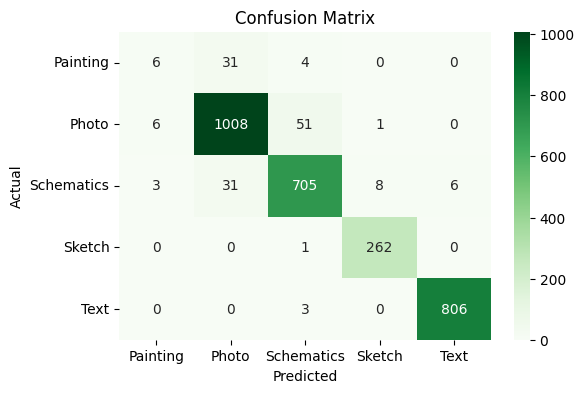

In [22]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        _, p = torch.max(out, 1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(p.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens",
            xticklabels=["Painting","Photo","Schematics","Sketch","Text"],
            yticklabels=["Painting","Photo","Schematics","Sketch","Text"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 6 Classification Report


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred,
                            target_names=["Painting","Photo","Schematics","Sketch","Text"]))


              precision    recall  f1-score   support

    Painting       0.40      0.15      0.21        41
       Photo       0.94      0.95      0.94      1066
  Schematics       0.92      0.94      0.93       753
      Sketch       0.97      1.00      0.98       263
        Text       0.99      1.00      0.99       809

    accuracy                           0.95      2932
   macro avg       0.84      0.80      0.81      2932
weighted avg       0.95      0.95      0.95      2932



# 7 Conclusion


this cnn based classifier model predicts with an accuracy of 95.05 %
the precision for painting image is low due the small weightage of the painting image dataset 
the model would learn better in case of a ideal uniform distributed dataset

the painting features may overlap with that of photos or sketches depending on the style